# 02 Inference Validation Notebook

This notebook is now the finished Faster R-CNN inference bridge.

What it does:
- loads the latest trained Faster R-CNN checkpoint from `checkpoints/neuro/`
- runs detector inference on a few DeepPCB test samples
- provides an interactive image-upload cell for ad hoc inference in Jupyter

What it does not do anymore:
- it does not own the symbolic export path
- it does not export legacy FC-head embeddings

The canonical symbolic export and SODT training path now belongs in `03_train_symbolic_sodt.ipynb`, where the detector is treated as the frozen teacher up to the RoI-pooled feature stage.


In [1]:
import io
from pathlib import Path

import ipywidgets as widgets
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from PIL import Image

from notebooks.util import resolve_root
from neuro.config import NeuroConfig, NeuroTrainConfig, load_yaml
from neuro.faster_rcnn import NeuroFasterRCNN
from neuro.prepare_dataset import PCBDataset
from neuro.preprocess_dataset import test_preprocess
from util.artifacts import latest_run_checkpoint
from util.device import select_device

PROJECT_ROOT = resolve_root()


In [2]:
train_config = load_yaml(Path('neuro_train.yaml'), NeuroTrainConfig)
neuro_config = load_yaml(Path('neuro.yaml'), NeuroConfig)

device = select_device(train_config['device'])
class_names = tuple(train_config['dataset']['class_names'])
checkpoint_dir = Path('checkpoints') / 'neuro'
checkpoint_path = latest_run_checkpoint(checkpoint_dir)
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)

model = NeuroFasterRCNN(
    neuro_config=neuro_config,
    train_config=train_config,
).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

checkpoint_path, checkpoint.get('metrics', {})


(PosixPath('checkpoints/neuro/run2.pt'),
 {'mAP@0.5:0.95': 0.7576388120651245,
  'mAP@0.5': 0.9799945950508118,
  'AP75': 0.908657431602478,
  'AP@50:5:85': 0.8981851935386658,
  'precision': 0.9013754755633596,
  'recall': 0.9808917197452229,
  'mar_100': 0.8529934883117676,
  'precision_recall_score_threshold': 0.5,
  'per_class_AP': {'open': 0.6775085926055908,
   'short': 0.6452382206916809,
   'mouse_bite': 0.7480947375297546,
   'spur': 0.723054826259613,
   'pinhole': 0.8867635130882263,
   'spurious_copper': 0.865172803401947}})

In [3]:
test_dataset = PCBDataset(train_config, 'test.txt')
test_dataset.add_preprocess(test_preprocess())


def run_detector(images: list[torch.Tensor]) -> list[dict[str, torch.Tensor]]:
    with torch.inference_mode():
        outputs = model([image.to(device) for image in images])
    return [
        {key: value.detach().cpu() for key, value in output.items()}
        for output in outputs
    ]


def visualize_prediction(image: torch.Tensor, prediction: dict[str, torch.Tensor], score_threshold: float = 0.3, title: str | None = None) -> None:
    figure, axis = plt.subplots(figsize=(7, 7))
    axis.imshow(image.detach().cpu().permute(1, 2, 0).clamp(0.0, 1.0).numpy())
    axis.axis('off')

    for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
        if float(score) < score_threshold:
            continue

        x1, y1, x2, y2 = box.tolist()
        width = x2 - x1
        height = y2 - y1
        class_name = class_names[int(label) - 1] if 0 < int(label) <= len(class_names) else str(int(label))

        axis.add_patch(
            patches.Rectangle(
                (x1, y1),
                width,
                height,
                linewidth=2,
                edgecolor='#d62828',
                facecolor='none',
            )
        )
        axis.text(
            x1,
            max(y1 - 4, 0),
            f'{class_name} {float(score):.2f}',
            color='white',
            fontsize=9,
            backgroundcolor='black',
        )

    if title is not None:
        axis.set_title(title, loc='left')

    plt.show()


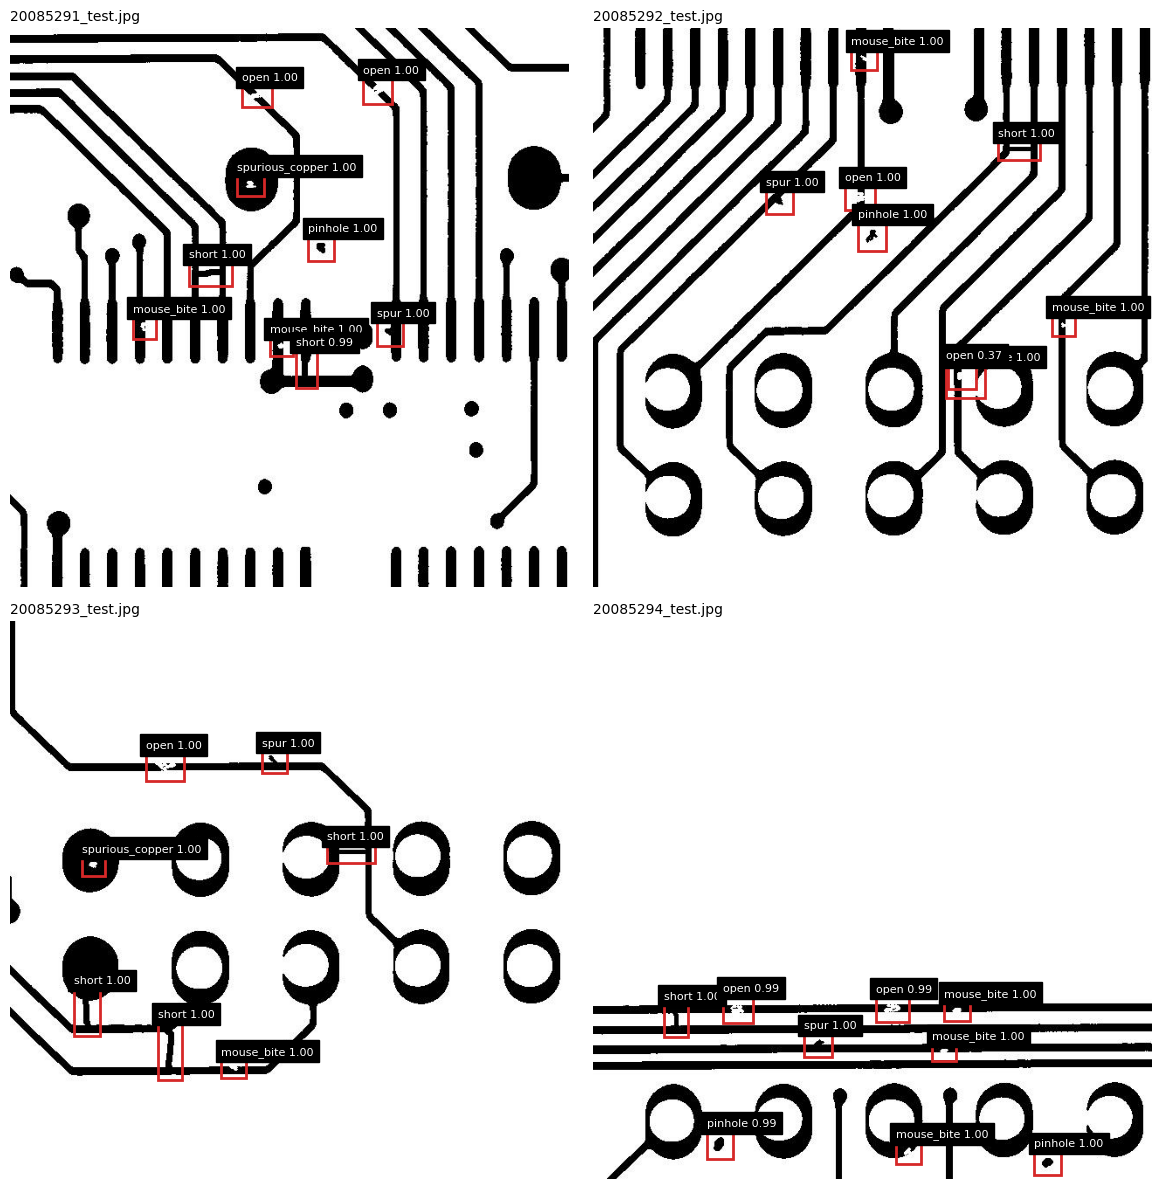

In [4]:
example_indices = [0, 1, 2, 3]
images = [test_dataset[index][0] for index in example_indices]
predictions = run_detector(images)

figure, axes = plt.subplots(2, 2, figsize=(12, 12))
for axis, dataset_index, image, prediction in zip(axes.flat, example_indices, images, predictions):
    axis.imshow(image.detach().cpu().permute(1, 2, 0).clamp(0.0, 1.0).numpy())
    axis.axis('off')
    axis.set_title(test_dataset.samples[dataset_index].image_path.name, loc='left', fontsize=10)

    for box, label, score in zip(prediction['boxes'], prediction['labels'], prediction['scores']):
        if float(score) < 0.3:
            continue
        x1, y1, x2, y2 = box.tolist()
        width = x2 - x1
        height = y2 - y1
        class_name = class_names[int(label) - 1] if 0 < int(label) <= len(class_names) else str(int(label))
        axis.add_patch(
            patches.Rectangle(
                (x1, y1),
                width,
                height,
                linewidth=2,
                edgecolor='#d62828',
                facecolor='none',
            )
        )
        axis.text(
            x1,
            max(y1 - 4, 0),
            f'{class_name} {float(score):.2f}',
            color='white',
            fontsize=8,
            backgroundcolor='black',
        )

figure.tight_layout()
plt.show()


## Upload Your Own Image

This section adds a Jupyter-native upload button using `ipywidgets.FileUpload`.
Click the upload button, choose one image from your computer, then click `Run Inference`.

Notes:
- this works in Jupyter notebooks and JupyterLab when `ipywidgets` is available
- the detector still applies its own internal Faster R-CNN preprocessing during inference
- this is for detector validation only; the RoI export for SODT stays in notebook `03`


In [ ]:
upload_widget = widgets.FileUpload(
    accept='image/*',
    multiple=False,
    description='Upload Image',
)
score_threshold_widget = widgets.FloatSlider(
    value=0.3,
    min=0.05,
    max=0.95,
    step=0.05,
    description='Score',
    readout_format='.2f',
)
run_button = widgets.Button(
    description='Run Inference',
    button_style='primary',
)
output_widget = widgets.Output()


def _uploaded_file_record(upload_value):
    if isinstance(upload_value, tuple):
        return upload_value[0] if upload_value else None
    if isinstance(upload_value, dict):
        if 'content' in upload_value:
            return upload_value
        if upload_value:
            first_value = next(iter(upload_value.values()))
            if isinstance(first_value, dict) and 'content' in first_value:
                return first_value
    return None


def _run_uploaded_inference(_button):
    file_record = _uploaded_file_record(upload_widget.value)
    with output_widget:
        output_widget.clear_output(wait=True)
        if file_record is None:
            print('Upload one image first.')
            return

        image_bytes = file_record['content']
        image_name = file_record.get('name', 'uploaded_image')
        pil_image = Image.open(io.BytesIO(image_bytes)).convert('RGB')
        image_tensor = test_preprocess()(pil_image)
        prediction = run_detector([image_tensor])[0]
        visualize_prediction(
            image_tensor,
            prediction,
            score_threshold=float(score_threshold_widget.value),
            title=image_name,
        )


run_button.on_click(_run_uploaded_inference)

display(
    widgets.VBox(
        [
            widgets.HTML('<b>Upload a local image and run Faster R-CNN inference</b>'),
            upload_widget,
            score_threshold_widget,
            run_button,
            output_widget,
        ]
    )
)


## Next Step

After validating detector inference here, continue to `03_train_symbolic_sodt.ipynb` for the canonical teacher export and SODT training pipeline based on RoI-pooled features.
